# This notebook will be used to create a data preprocessing pipeline

## 1. Extracting Data and initial visualization

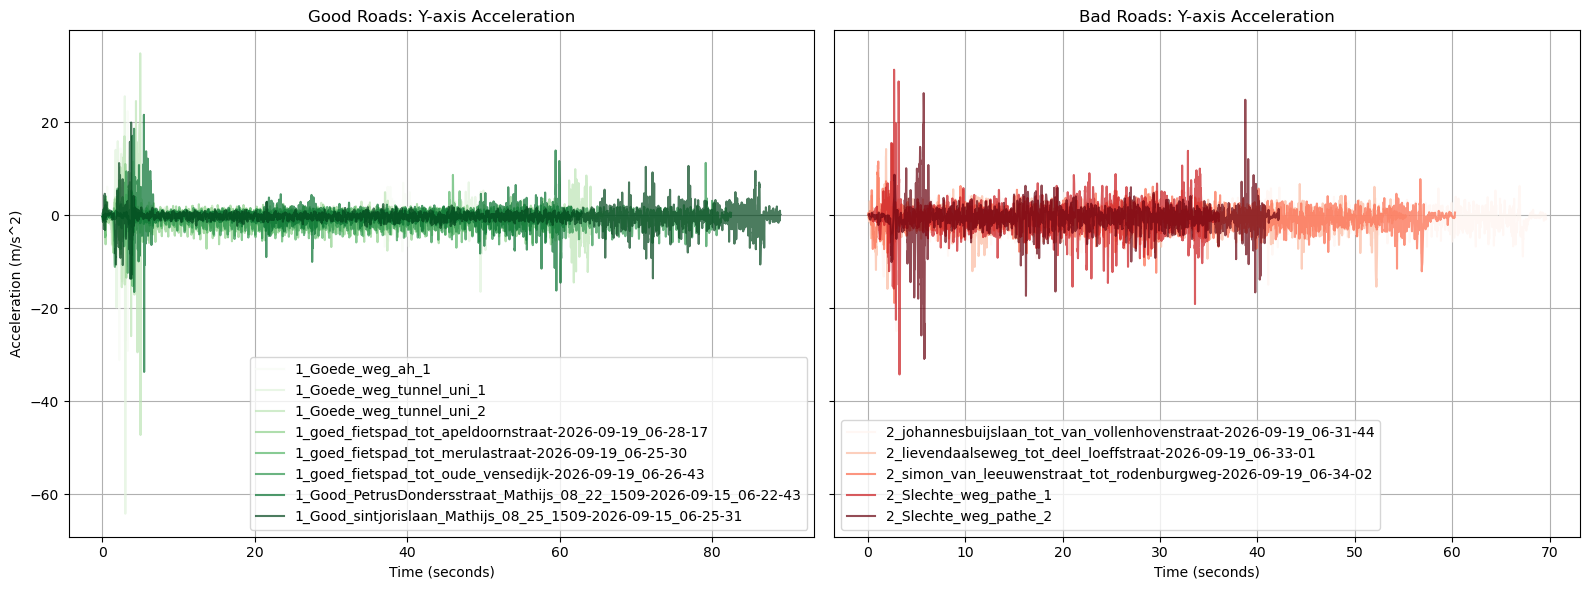

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Automatically discover all good roads (starting with "1") and bad roads (starting with "2")
good_paths = glob.glob("data/1_*/**/Accelerometer.csv", recursive=True)
if not good_paths:
    good_paths = glob.glob("data/1_*/Accelerometer.csv")

bad_paths = glob.glob("data/2_*/**/Accelerometer.csv", recursive=True)
if not bad_paths:
    bad_paths = glob.glob("data/2_*/Accelerometer.csv")

# Create a figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Generate distinct shades of green for good roads dynamically
good_colors = plt.cm.Greens(
    [i / max(1, len(good_paths) - 1) for i in range(len(good_paths))]
)

# Plot all good road recordings
for path, color in zip(good_paths, good_colors):
    df = pd.read_csv(path)
    # Extract folder name to use as a dynamic label
    label = path.split(os.sep)[-2]
    ax1.plot(df['seconds_elapsed'], df['y'], label=label, color=color, alpha=0.7)

ax1.set_title("Good Roads: Y-axis Acceleration")
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Acceleration (m/s^2)")
ax1.legend()
ax1.grid(True)

# Generate distinct shades of red for bad roads dynamically
bad_colors = plt.cm.Reds(
    [i / max(1, len(bad_paths) - 1) for i in range(len(bad_paths))]
)

# Plot all bad road recordings
for path, color in zip(bad_paths, bad_colors):
    df = pd.read_csv(path)
    label = path.split(os.sep)[-2]
    ax2.plot(df['seconds_elapsed'], df['y'], label=label, color=color, alpha=0.7)

ax2.set_title("Bad Roads: Y-axis Acceleration")
ax2.set_xlabel("Time (seconds)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 2. Cut and Synchronise Data

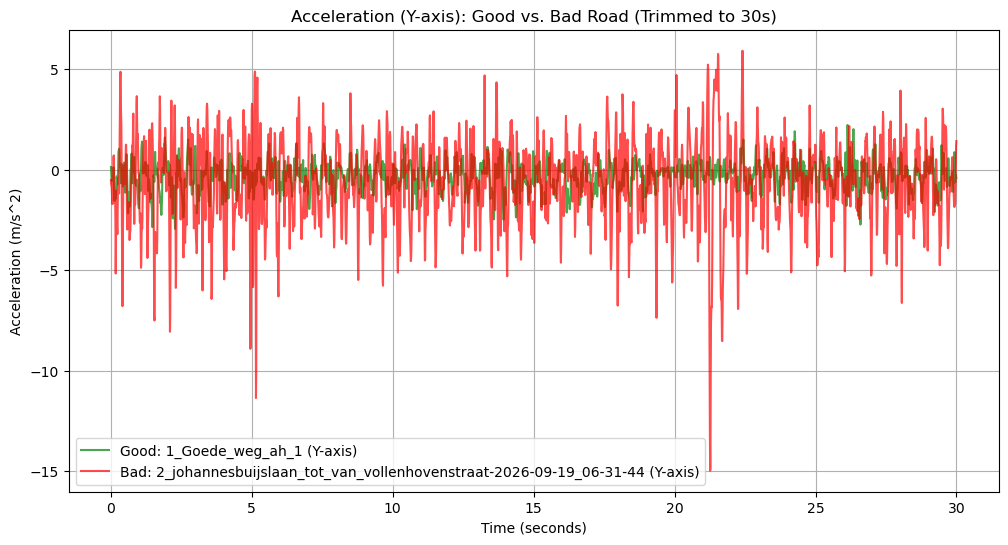

In [2]:
def trim_to_30s(df):
    """Trims dataframe symmetrically to a duration of 30 seconds."""
    start_time = df['seconds_elapsed'].min()
    end_time = df['seconds_elapsed'].max()
    total_duration = end_time - start_time
    
    if total_duration > 30:
        trim_amount = (total_duration - 30) / 2
        new_start = start_time + trim_amount
        new_end = end_time - trim_amount
        
        # Filter rows within the 30-second window and reset elapsed time from 0
        df_trimmed = df[(df['seconds_elapsed'] >= new_start) & (df['seconds_elapsed'] <= new_end)].copy()
        df_trimmed['seconds_elapsed'] = df_trimmed['seconds_elapsed'] - new_start
        return df_trimmed
    return df

# Process and trim all discovered good road recordings dynamically
good_roads_trimmed = {}
for path in good_paths:
    key = path.split(os.sep)[-2]
    df = pd.read_csv(path)
    good_roads_trimmed[key] = trim_to_30s(df)

# Process and trim all discovered bad road recordings dynamically
bad_roads_trimmed = {}
for path in bad_paths:
    key = path.split(os.sep)[-2]
    df = pd.read_csv(path)
    bad_roads_trimmed[key] = trim_to_30s(df)

# Plotting example: Y-axis comparison of a sample good and bad road after trimming
plt.figure(figsize=(12, 6))

if good_roads_trimmed:
    first_good_key = list(good_roads_trimmed.keys())[0]
    df_g = good_roads_trimmed[first_good_key]
    plt.plot(df_g['seconds_elapsed'], df_g['y'], label=f'Good: {first_good_key} (Y-axis)', color='green', alpha=0.7)

if bad_roads_trimmed:
    first_bad_key = list(bad_roads_trimmed.keys())[0]
    df_b = bad_roads_trimmed[first_bad_key]
    plt.plot(df_b['seconds_elapsed'], df_b['y'], label=f'Bad: {first_bad_key} (Y-axis)', color='red', alpha=0.7)

plt.title('Acceleration (Y-axis): Good vs. Bad Road (Trimmed to 30s)')
plt.xlabel('Time (seconds)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Windowing, Band-Pass Filter and Statistics

In [3]:
import numpy as np
from scipy.signal import butter, lfilter
from scipy.stats import skew, kurtosis

# 1. Bandpass filter definitions
def butter_bandpass(lowcut, highcut, fs, order=4):
    """Design a Butterworth bandpass filter."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    """Apply the bandpass filter to a data array."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return lfilter(b, a, data)

# 2. Windowing and Feature Extraction function (including Skewness & Kurtosis)
def create_windows_and_filter(df, window_size_sec=2.0, overlap=0.5, fs=100.0):
    """Apply sliding windows and extract statistical features from the Y-axis."""
    df_filtered = df.copy()
    # Apply bandpass filter to the Y-axis
    df_filtered['y_filtered'] = bandpass_filter(df['y'], lowcut=0.5, highcut=20.0, fs=fs)
    
    window_size_samples = int(window_size_sec * fs)
    step_size = int(window_size_samples * (1 - overlap))
    
    features_list = []
    
    for start in range(0, len(df_filtered) - window_size_samples, step_size):
        window = df_filtered.iloc[start:start + window_size_samples]
        sig = window['y_filtered']
        
        # Extract features per window
        feat = {
            'mean': sig.mean(),
            'std': sig.std(),
            'rms': np.sqrt(np.mean(sig**2)),
            'peak_to_peak': sig.max() - sig.min(),
            'iqr': np.percentile(sig, 75) - np.percentile(sig, 25),
            'skewness': skew(sig),
            'kurtosis': kurtosis(sig)
        }
        features_list.append(feat)
        
    return pd.DataFrame(features_list)

# 3. Process ALL trimmed good roads and combine them into a single master dataframe
all_good_features = []
for key, df_trimmed in good_roads_trimmed.items():
    feat_df = create_windows_and_filter(df_trimmed)
    feat_df['source'] = key
    all_good_features.append(feat_df)

features_good = pd.concat(all_good_features, ignore_index=True)

# 4. Process ALL trimmed bad roads and combine them into a single master dataframe
all_bad_features = []
for key, df_trimmed in bad_roads_trimmed.items():
    feat_df = create_windows_and_filter(df_trimmed)
    feat_df['source'] = key
    all_bad_features.append(feat_df)

features_bad = pd.concat(all_bad_features, ignore_index=True)

# 5. Display summary results
print(f"Total feature windows generated for good roads: {len(features_good)}")
print(f"Total feature windows generated for bad roads: {len(features_bad)}")
print("\nFeature sample preview (Good roads):\n", features_good.head(3))

Total feature windows generated for good roads: 232
Total feature windows generated for bad roads: 145

Feature sample preview (Good roads):
        mean       std       rms  peak_to_peak       iqr  skewness  kurtosis  \
0  0.049653  0.808794  0.808296      3.658493  1.092390  0.302002 -0.435841   
1  0.006411  0.944952  0.942608      4.023340  1.438405  0.233579 -0.786159   
2 -0.035088  0.830046  0.828711      3.944835  1.064213 -0.098178 -0.296823   

             source  
0  1_Goede_weg_ah_1  
1  1_Goede_weg_ah_1  
2  1_Goede_weg_ah_1  


## 4. Visualization of Statistics

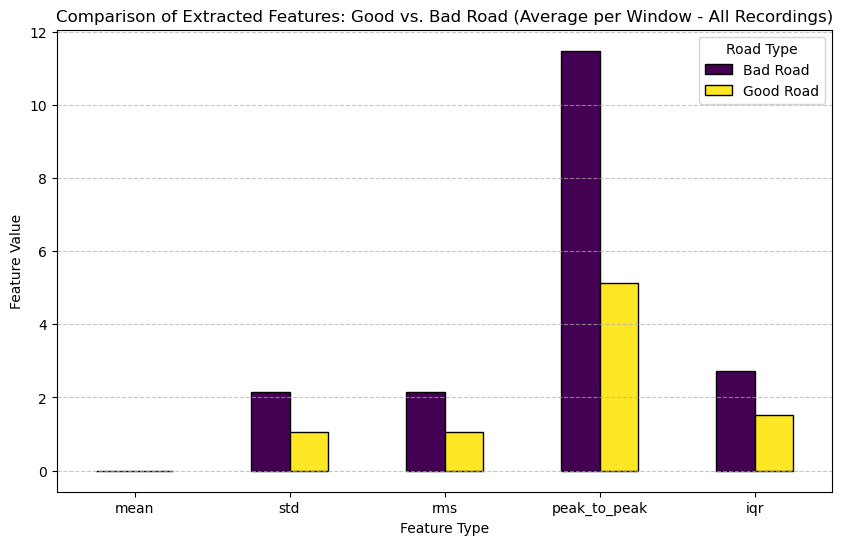

In [4]:
# Prepare copies of our master feature dataframes
features_good_viz = features_good.copy()
features_bad_viz = features_bad.copy()

# Add a road type label to distinguish between datasets
features_good_viz['road_type'] = 'Good Road'
features_bad_viz['road_type'] = 'Bad Road'

# Combine both datasets into a single dataframe for easy comparison
df_combined = pd.concat([features_good_viz, features_bad_viz], ignore_index=True)

# Select the feature columns we want to compare across road types
feature_cols = ['mean', 'std', 'rms', 'peak_to_peak', 'iqr']

# Calculate the average value for each feature per road type across all recordings
mean_comparison = df_combined.groupby('road_type')[feature_cols].mean()

# Create a grouped bar chart to visualize the differences
ax = mean_comparison.T.plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black')
plt.title('Comparison of Extracted Features: Good vs. Bad Road (Average per Window - All Recordings)')
plt.ylabel('Feature Value')
plt.xlabel('Feature Type')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Road Type')
plt.show()